Linear Regression for Single Variable

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [44]:
df = pd.read_csv("homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


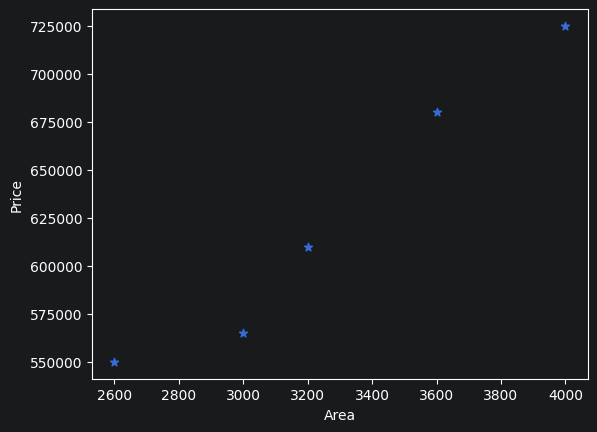

In [45]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.area,df.price,marker='*')

In [46]:
rg = linear_model.LinearRegression()

In [47]:
rg.fit(df[["area"]],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


when passing a py list, a warning comes . so better to pass it as a df

In [48]:
#rg.predict([[3300]])
new_house= pd.DataFrame(
    {'area':[3300,5500]} #x value
)
rg.predict(new_house)

array([628715.75342466, 927448.63013699])

braking down math behind the above

In [49]:
rg.coef_ #m

array([135.78767123])

In [50]:
rg.intercept_ #c

np.float64(180616.43835616432)

In [51]:
# y = mx+c
135.78767123*3300+180616.43835616432
#both answers are same.

628715.7534151643

In [52]:
135.78767123*5500+180616.43835616432
#compare answers

927448.6301211643

In [53]:
d= pd.read_csv("areas.csv")
d.head(3)

,area
0,1000
1,1500
2,2300


no prices going to predict it

In [54]:
p=rg.predict(d) #price is predicted

In [55]:
d['prices']= p

In [56]:
d

,area,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [57]:
d.to_csv("prediction.csv",index=False) #index removed

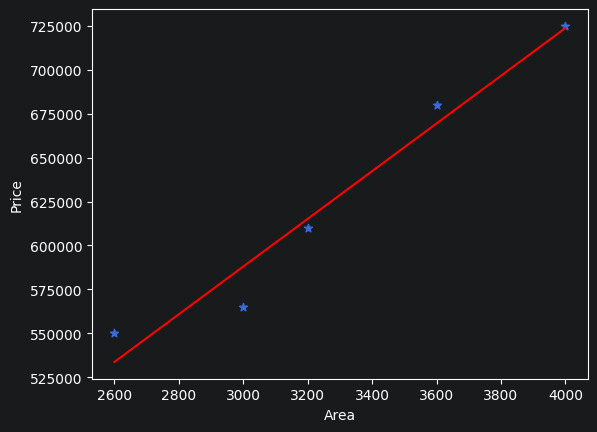

In [58]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.area,df.price,marker='*')
plt.plot(df.area,rg.predict(df[["area"]]),color='red')

In [59]:
import pickle

exporting file

In [60]:
with open('model_pickle', 'wb') as f:
    pickle.dump(rg, f)

loading file

In [61]:
with open('model_pickle', 'rb') as f:
    model = pickle.load(f)

In [64]:
model.predict([[5000]])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

In [67]:
import joblib #for large numpy arrays

In [69]:
joblib.dump(model,'model_joblib')

['model_joblib']

In [71]:
mj = joblib.load('model_joblib')
mj.predict([[5000]])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])